In [1]:
!pip install -q rfdetr supervision opencv-python matplotlib seaborn

In [2]:
!pip install -q faster-coco-eval

In [3]:
DATASET_DIR = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"

In [4]:
import yaml

yaml_path = f"{DATASET_DIR}/data.yaml"

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]

print("Number of classes:", len(CLASS_NAMES))
print(CLASS_NAMES)

Number of classes: 25
['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']


In [5]:
import pandas as pd

MANIFEST = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/images_manifest.csv"

df = pd.read_csv(MANIFEST)

print(df.head())
print(df.shape)

   split image_filename label_filename  num_objects classes_present  \
0  train  IMG_00001.jpg  IMG_00001.txt            1               2   
1  train  IMG_00002.jpg  IMG_00002.txt            1               2   
2  train  IMG_00003.jpg  IMG_00003.txt            2               2   
3  train  IMG_00004.jpg  IMG_00004.txt            1               2   
4  train  IMG_00005.jpg  IMG_00005.txt            1               2   

  class_names_present  
0                 Car  
1                 Car  
2                 Car  
3                 Car  
4                 Car  
(24326, 6)


In [6]:
from collections import defaultdict
import ast

class_to_images = defaultdict(list)

for _, row in df.iterrows():

    split = row["split"]

    try:
        classes = ast.literal_eval(
            row["class_names_present"]
        )
    except:
        continue

    for cls in classes:
        class_to_images[(split, cls)].append(
            row["image_filename"]
        )

In [7]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import ast

DATASET_DIR = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"

def draw_yolo_boxes(image, label_path):

    h, w = image.shape[:2]

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls, xc, yc, bw, bh = map(float, line.split())

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        cls = int(cls)

        cv2.rectangle(
            image,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

        cv2.putText(
            image,
            CLASS_NAMES[cls],
            (x1,max(20,y1)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    return image

In [8]:
def EDA(split="train",
        class_name="Car",
        n=5):

    rows = df[
        (df["split"] == split) &
        (
            df["class_names_present"]
            .str.contains(class_name,
                          case=False,
                          na=False)
        )
    ]

    if len(rows) == 0:
        print("No images found")
        return

    rows = rows.sample(
        min(n, len(rows)),
        random_state=None
    )

    fig, axes = plt.subplots(
        1,
        len(rows),
        figsize=(5*len(rows),5)
    )

    if len(rows) == 1:
        axes = [axes]

    for ax, (_, row) in zip(
        axes,
        rows.iterrows()
    ):

        img_path = os.path.join(
            DATASET_DIR,
            split,
            "images",
            row["image_filename"]
        )

        label_path = os.path.join(
            DATASET_DIR,
            split,
            "labels",
            row["label_filename"]
        )

        img = cv2.imread(img_path)
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = draw_yolo_boxes(
            img,
            label_path
        )

        ax.imshow(img)
        ax.axis("off")

    plt.suptitle(
        f"{class_name} ({split})",
        fontsize=18
    )

    plt.show()

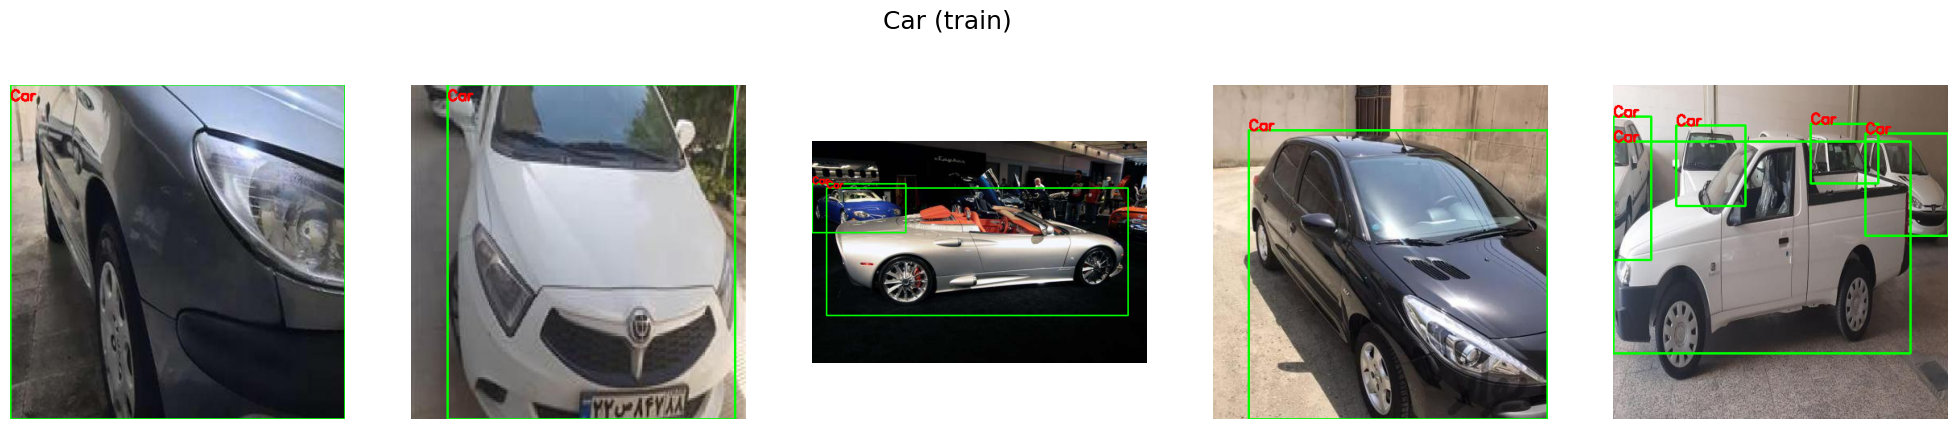

In [9]:
EDA("train", "Car", 5)
# EDA("train", "Person", 5)
# EDA("train", "Traffic sign", 5)

In [10]:
import os
import cv2
import numpy as np

image_dir = f"{DATASET_DIR}/train/images"

sizes = []

for f in os.listdir(image_dir)[:500]:
    img = cv2.imread(os.path.join(image_dir, f))
    h, w = img.shape[:2]
    sizes.append((w, h))

sizes = np.array(sizes)

print("Mean:", sizes.mean(axis=0))
print("Max :", sizes.max(axis=0))

Mean: [591.824 582.02 ]
Max : [1024  768]


In [14]:
import os
import cv2
import shutil
from tqdm import tqdm

SRC = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"
DST = "/kaggle/working/dataset_576"

SIZE = 576

os.makedirs(DST, exist_ok=True)

for split in ["train", "valid", "test"]:

    os.makedirs(f"{DST}/{split}/images", exist_ok=True)
    os.makedirs(f"{DST}/{split}/labels", exist_ok=True)

    img_src = f"{SRC}/{split}/images"
    lbl_src = f"{SRC}/{split}/labels"

    img_dst = f"{DST}/{split}/images"
    lbl_dst = f"{DST}/{split}/labels"

    print(f"Processing {split}")

    for img_file in tqdm(os.listdir(img_src)):

        src_img = os.path.join(img_src, img_file)
        dst_img = os.path.join(img_dst, img_file)

        if split == "train":

            img = cv2.imread(src_img)

            img = cv2.resize(
                img,
                (SIZE, SIZE),
                interpolation=cv2.INTER_AREA
            )

            cv2.imwrite(dst_img, img)

        else:
            shutil.copy2(src_img, dst_img)

    for lbl_file in os.listdir(lbl_src):

        shutil.copy2(
            os.path.join(lbl_src, lbl_file),
            os.path.join(lbl_dst, lbl_file)
        )

Processing train


100%|██████████| 19186/19186 [02:49<00:00, 113.51it/s]


Processing valid


100%|██████████| 3511/3511 [00:09<00:00, 354.70it/s]


Processing test


100%|██████████| 1629/1629 [00:18<00:00, 86.22it/s]


In [15]:
import shutil

shutil.copy2(
    f"{SRC}/data.yaml",
    f"{DST}/data.yaml"
)

'/kaggle/working/dataset_576/data.yaml'

In [16]:
import cv2
import os

sample = os.listdir(
    f"{DST}/train/images"
)[0]

img = cv2.imread(
    f"{DST}/train/images/{sample}"
)

print(img.shape)

(576, 576, 3)


In [17]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [18]:
from rfdetr import RFDETRMedium

model = RFDETRMedium()

[2026-06-13 08:25:57] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-13 08:25:57] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-13 08:25:57] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-13 08:25:59] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


In [20]:
from rfdetr import RFDETRMedium

model = RFDETRMedium()

model.train(
    dataset_dir="/kaggle/working/dataset_576",
    epochs=10,
    batch_size=4,
    grad_accum_steps=2,
    resolution=576,
    gradient_checkpointing=True,
    lr=1e-4,
    output_dir="/kaggle/working/rfdetr_medium"
)

[2026-06-13 08:26:44] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-13 08:26:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-13 08:26:44] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-13 08:26:45] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-13 08:26:47] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-13 08:26:47] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-13 08:26:48] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


...

Output()

[2026-06-13 08:26:57] [INFO] rf-detr - Best EMA mAP improved to 0.1995 (epoch 0)



Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 469, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [23]:
import os

for root, dirs, files in os.walk(
    "/kaggle/working/rfdetr_medium"
):
    for f in files:
        if f.endswith(".ckpt"):
            print(os.path.join(root,f))

In [22]:
BEST_MODEL = "/kaggle/working/rfdetr_medium/checkpoints/best.ckpt"

In [24]:
# from rfdetr import RFDETRMedium

# model = RFDETRMedium()

# model.load_checkpoint(BEST_MODEL)

[2026-06-13 08:56:53] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


[2026-06-13 08:56:53] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-13 08:56:53] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-13 08:56:54] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-medium.pth already exists with correct MD5 hash.


AttributeError: 'RFDETRMedium' object has no attribute 'load_checkpoint'

In [ ]:
# import cv2
# import matplotlib.pyplot as plt

# image_path = "/kaggle/input/your_image.jpg"

# image = cv2.imread(image_path)

# predictions = model.predict(image)

In [ ]:
import supervision as sv

image = cv2.imread(image_path)

detections = sv.Detections.from_inference(
    predictions
)

box_annotator = sv.BoxAnnotator()

label_annotator = sv.LabelAnnotator()

labels = [
    f"{CLASS_NAMES[c]} {conf:.2f}"
    for c, conf in zip(
        detections.class_id,
        detections.confidence
    )
]

annotated = box_annotator.annotate(
    scene=image.copy(),
    detections=detections
)

annotated = label_annotator.annotate(
    scene=annotated,
    detections=detections,
    labels=labels
)

plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
))
plt.axis("off")
plt.show()

In [ ]:
results = model.evaluate()

print(results)